# Hierarchical Bootstrap

This notebook demonstrates how to run a **hierarchical bootstrap** — a resampling method designed for nested/clustered data (e.g., multiple neurons per animal, multiple trials per session). It is inspired by the approach in [Saravanan et al. (2020)](https://pmc.ncbi.nlm.nih.gov/articles/PMC7906290/), authored by [Michael Preston](https://www.linkedin.com/in/michael-preston-jr/) and edited by [Ashley Juavinett](http://www.ashleyjuavinett.com).

## Import packages

First, we need to import NumPy and pandas for data handling. Then, we'll define the custom functions needed to implement hierarchical boostrapping.

In [7]:
# imports
import numpy as np
import pandas as pd

In [ ]:
# @title Helper functions { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def hierarchical_resampling(df, variable, level_1, level_2, iterations):
    clusters = df[level_1].unique()
    n_clusters = len(clusters)
    instances_per_cluster = np.zeros(n_clusters)
    for i_cluster, cluster_i in enumerate(clusters):
        instances_per_cluster[i_cluster] = len(df.loc[df[level_1]==cluster_i, level_2].unique())
    n_instances = int(np.nanmean(instances_per_cluster))
    cluster_instance_map = {cluster: df.loc[df[level_1] == cluster, level_2].unique() for cluster in clusters}
    distribution = np.zeros(iterations)
    for i_iteration in range(iterations):
        clusters_resampled = np.random.choice(clusters, size=n_clusters)
        values = []
        for i_cluster, cluster_i in enumerate(clusters_resampled):
            instances = cluster_instance_map[cluster_i]
            instances_resampled = np.random.choice(instances, size=n_instances)
            for _, instance_i in enumerate(instances_resampled):
                value = df.loc[(df[level_1]==cluster_i) & (df[level_2]==instance_i), variable].values[0]
                values.append(value)
        distribution[i_iteration] = np.nanmean(values)
    return distribution


def compute_p_value(distribution):
    n_greater = np.sum(distribution > 0)
    n_less = np.sum(distribution < 0)
    p_value = np.min([n_greater, n_less]) / len(distribution)
    sign = np.sign(n_greater - n_less)
    return p_value, sign


def check_input(df, variable, level_1, level_2, condition=None):
    if variable not in df.columns:
        raise ValueError(f"Variable '{variable}' not found in dataframe.")
    if (condition not in df.columns) and (condition is not None):
        raise ValueError(f"Condition '{condition}' not found in dataframe.")
    if level_1 not in df.columns:
        raise ValueError(f"Level 1 '{level_1}' not found in dataframe.")
    if level_2 not in df.columns:
        raise ValueError(f"Level 2 '{level_2}' not found in dataframe.")
    if condition is not None:
        df = _drop_missing_data(df, level_1, level_2, condition, variable)
    return df


def _drop_missing_data(df, level_1, level_2, condition, variable):
    n_dropped = 0
    n_instances = 0
    clusters = df[level_1].unique()
    for cluster in clusters:
        instances = df.loc[df[level_1]==cluster, level_2].unique()
        for instance in instances:
            df_i = df.loc[(df[level_1]==cluster) & (df[level_2]==instance)]
            if (len(df_i) != 2) or (len(df_i[condition].unique()) != 2) or (df_i[variable].isnull().any()):
                df = df.drop(df_i.index)
                n_dropped += 1
            n_instances += 1
    if n_dropped > 0:
        print(f"Warning: {n_dropped}/{n_instances} instances dropped due to missing data.")
    return df


# ── Two-sample hierarchical bootstrap ─────────────────────────────────────────

def twosample_hierarchical_bootstrap(df, variable, condition, level_1, level_2,
                                     n_iterations=1000, verbose=True, plot=True, **kwargs):
    df_0, df_1 = _twosample_split_conditions(df, condition)
    distribution_0 = hierarchical_resampling(df_0, variable, level_1, level_2, n_iterations)
    distribution_1 = hierarchical_resampling(df_1, variable, level_1, level_2, n_iterations)
    p_value, joint_prob, bin_edges = _twosample_compute_p_value(distribution_0, distribution_1)
    if verbose:
        print(f"p-value: {p_value:.3f}")
    if plot:
        _twosample_plot_results(df, variable, condition, distribution_0, distribution_1,
                                joint_prob, bin_edges, **kwargs)
    return p_value, joint_prob, bin_edges, distribution_0, distribution_1


def _twosample_split_conditions(df, condition):
    conditions = np.sort(df[condition].unique())
    if len(conditions) != 2:
        raise ValueError("More than two experimental conditions detected.")
    df_0 = df.loc[df[condition]==conditions[0]]
    df_1 = df.loc[df[condition]==conditions[1]]
    return df_0, df_1


def _twosample_compute_p_value(distribution_0, distribution_1, n_bins=30):
    all_values = np.concatenate([distribution_0, distribution_1])
    bin_edges = np.linspace(np.min(all_values), np.max(all_values), n_bins)
    bin_width = bin_edges[1] - bin_edges[0]
    bin_edges = np.append(bin_edges, bin_edges[-1] + bin_width) - (bin_width/2)
    prob_0 = np.histogram(distribution_0, bins=bin_edges)[0] / len(distribution_0)
    prob_1 = np.histogram(distribution_1, bins=bin_edges)[0] / len(distribution_1)
    joint_prob = np.outer(prob_0, prob_1)
    joint_prob = joint_prob / np.sum(joint_prob)
    p_value = np.sum(np.triu(joint_prob))
    return p_value, joint_prob, bin_edges


def _twosample_plot_results(df, variable, condition, distribution_0, distribution_1,
                            joint_prob, bin_edges, colors=['k', 'b'], labels=['0', '1']):
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 4))
    conditions = np.sort(df[condition].unique())
    data_0 = df.loc[df[condition]==conditions[0], variable].values
    data_1 = df.loc[df[condition]==conditions[1], variable].values
    bin_edges_ = np.linspace(np.nanmin([data_0, data_1]), np.nanmax([data_0, data_1]), 30)
    ax0.hist(data_0.ravel(), bins=bin_edges_, color=colors[0], alpha=0.5, label=labels[0])
    ax0.hist(data_1.ravel(), bins=bin_edges_, color=colors[1], alpha=0.5, label=labels[1])
    ax0.set_xlabel('value'); ax0.set_ylabel('count'); ax0.set_title('Original dataset')
    ax1.hist(distribution_0, bins=bin_edges, color='k', alpha=0.5, label=conditions[0])
    ax1.hist(distribution_1, bins=bin_edges, color='b', alpha=0.5, label=conditions[1])
    ax1.set_xlabel(variable); ax1.set_ylabel('count'); ax1.set_title('Bootstrap results'); ax1.legend()
    im = ax2.pcolormesh(bin_edges, bin_edges, joint_prob, cmap='hot')
    ax2.set_xlabel(conditions[0]); ax2.set_ylabel(conditions[1]); ax2.set_title('Joint probability')
    fig.colorbar(im, ax=ax2)


# ── Paired hierarchical bootstrap ─────────────────────────────────────────────

def paired_hierarchical_bootstrap(df, variable, condition, level_1, level_2,
                                  n_iterations=1000, verbose=True, plot=True):
    distribution = _paired_hierarchical_resampling(df, variable, condition, level_1, level_2, n_iterations)
    p_value, sign = compute_p_value(distribution)
    conditions = df[condition].unique()
    df_pivot = df.pivot(index=[level_1, level_2], columns=condition, values=variable).reset_index()
    df_pivot['difference'] = df_pivot[conditions[1]] - df_pivot[conditions[0]]
    true_mean = np.nanmean(df_pivot['difference'])
    if verbose:
        _paired_print_results(p_value, true_mean, n_iterations, conditions)
    if plot:
        _paired_plot_results(df, variable, condition, level_1, level_2, distribution)
    return p_value, sign, distribution, true_mean


def _paired_hierarchical_resampling(df, variable, condition, level_1, level_2, iterations):
    clusters = df[level_1].unique()
    n_clusters = len(clusters)
    conditions = df[condition].unique()
    if len(conditions) != 2:
        raise ValueError("Condition must have two unique values.")
    instances_per_cluster = np.zeros(n_clusters)
    for i_cluster, cluster_i in enumerate(clusters):
        instances_per_cluster[i_cluster] = len(df.loc[df[level_1]==cluster_i, level_2].unique())
    n_instances = int(np.nanmean(instances_per_cluster))
    cluster_instance_map = {cluster: df.loc[df[level_1] == cluster, level_2].unique() for cluster in clusters}
    distribution = np.zeros(iterations)
    for i_iteration in range(iterations):
        clusters_resampled = np.random.choice(clusters, size=n_clusters)
        values = np.zeros([n_clusters, n_instances, 2])
        for i_cluster, cluster_i in enumerate(clusters_resampled):
            instances = cluster_instance_map[cluster_i]
            instances_resampled = np.random.choice(instances, size=n_instances)
            for i_instance, instance_i in enumerate(instances_resampled):
                values_ii = df.loc[(df[level_1]==cluster_i) & (df[level_2]==instance_i)]
                for i_cond, condition_i in enumerate(conditions):
                    value = values_ii.loc[values_ii[condition]==condition_i, variable].values
                    values[i_cluster, i_instance, i_cond] = value
        distribution[i_iteration] = _mean_difference(values[..., 0], values[..., 1])
    return distribution


def _mean_difference(data_a, data_b):
    if np.all(np.isnan(data_a)) or np.all(np.isnan(data_b)):
        return np.nan
    return np.nanmean(data_b) - np.nanmean(data_a)


def _paired_plot_results(df, variable, condition, level_1, level_2, distribution):
    df_pivot = df.pivot(index=[level_1, level_2], columns=condition, values=variable).reset_index()
    plotting_params = {'data': df, 'x': condition, 'y': variable}
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
    sns.violinplot(**plotting_params, ax=ax0, hue=condition, legend=False)
    sns.swarmplot(**plotting_params, ax=ax0, size=2, color='k', alpha=0.5)
    conditions = df[condition].unique()
    for i_chan in range(df_pivot.shape[0]):
        y = [df_pivot.loc[i_chan, conditions[0]], df_pivot.loc[i_chan, conditions[1]]]
        ax0.plot([0, 1], y, color='k', alpha=0.5, lw=0.5)
    ax0.set_title('Empirical data')
    ax1.hist(distribution, color='k', alpha=0.5)
    ax1.axvline(np.nanmean(distribution), color='r', label='mean')
    ax1.axvline(0, color='k', linestyle='--', label='null')
    ax1.set_xlabel(f"Δ {variable}"); ax1.set_ylabel('count')
    ax1.set_title('Resampled distribution'); ax1.legend()


def _paired_print_results(p_value, true_mean, n_iterations, conditions):
    if p_value == 0:
        print(f"p-value: <{1/n_iterations}")
    elif p_value < 0.001:
        print(f"p-value: {p_value:.2e}")
    else:
        print(f"p-value: {p_value:.3f}")
    print(f"True mean difference: {true_mean:.2f}")
    if true_mean < 0:
        print(f"Condition '{conditions[0]}' < '{conditions[1]}'")
    elif true_mean > 0:
        print(f"Condition '{conditions[0]}' > '{conditions[1]}'")
    else:
        print(f"Condition '{conditions[0]}' = '{conditions[1]}'")


# ── One-sample hierarchical bootstrap ─────────────────────────────────────────

def onesample_hierarchical_bootstrap(df, variable, level_1, level_2,
                                     n_iterations=1000, verbose=True, plot=True):
    distribution = hierarchical_resampling(df, variable, level_1, level_2, n_iterations)
    p_value, sign = compute_p_value(distribution)
    if verbose:
        print(f"p-value: {p_value:.3f}")
    if plot:
        _onesample_plot_results(df, variable, distribution)
    return p_value, sign, distribution


def _onesample_plot_results(df, variable, distribution):
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
    data = df[variable].values
    ax0.hist(data.ravel(), color='k', alpha=0.5)
    ax0.set_xlabel('value'); ax0.set_ylabel('count'); ax0.set_title('Original dataset')
    ax1.hist(distribution, color='k', alpha=0.5)
    ax1.axvline(np.nanmean(distribution), color='r', label='mean')
    ax1.axvline(0, color='k', linestyle='--', label='null')
    ax1.set_xlabel(variable); ax1.set_ylabel('count'); ax1.set_title('Bootstrap results')


# ── Main wrapper ───────────────────────────────────────────────────────────────

def hierarchical_bootstrap(df, variable, level_1, level_2, condition=None,
                           paired=False, one_sample=False, n_iterations=1000,
                           verbose=True, plot=True):
    df = check_input(df, variable, level_1, level_2, condition)
    if one_sample:
        return onesample_hierarchical_bootstrap(df, variable, level_1, level_2,
                                                n_iterations, verbose, plot)
    else:
        if condition is None:
            raise ValueError("Condition must be specified for two-sample test.")
        if paired:
            return paired_hierarchical_bootstrap(df, variable, condition,
                                                 level_1, level_2, n_iterations,
                                                 verbose, plot)
        else:
            return twosample_hierarchical_bootstrap(df, variable, condition,
                                                    level_1, level_2,
                                                    n_iterations, verbose, plot)

## Create example data (or upload your own)

Here we simulate a hierarchical dataset with two conditions, each containing multiple **clusters** (e.g., animals or subjects) and **instances** within each cluster (e.g., neurons or trials).

> **Task**: Replace `n_clusters` and `n_instances` with values that match your own data structure, and swap in your real dataframe below.

In [ ]:
# @title Helper functions { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ── Utility functions ──────────────────────────────────────────────────────────

def hierarchical_resampling(df, variable, level_1, level_2, iterations):
    """
    Return a bootstrap distribution of resampled means for hierarchical data.

    Resamples level_1 (clusters) with replacement, then resamples level_2
    (instances) within each drawn cluster. The number of instances per cluster
    is set to the average across clusters to avoid biasing toward larger clusters.

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — column to resample
    level_1 : str — higher hierarchy level (e.g. subject)
    level_2 : str — lower hierarchy level nested within level_1 (e.g. neuron)
    iterations : int — number of bootstrap iterations

    Returns
    -------
    distribution : np.ndarray, shape (iterations,) — resampled means
    """
    clusters = df[level_1].unique()
    n_clusters = len(clusters)
    instances_per_cluster = np.zeros(n_clusters)
    for i_cluster, cluster_i in enumerate(clusters):
        instances_per_cluster[i_cluster] = len(df.loc[df[level_1]==cluster_i, level_2].unique())
    n_instances = int(np.nanmean(instances_per_cluster))
    cluster_instance_map = {cluster: df.loc[df[level_1] == cluster, level_2].unique() for cluster in clusters}
    distribution = np.zeros(iterations)
    for i_iteration in range(iterations):
        clusters_resampled = np.random.choice(clusters, size=n_clusters)
        values = []
        for i_cluster, cluster_i in enumerate(clusters_resampled):
            instances = cluster_instance_map[cluster_i]
            instances_resampled = np.random.choice(instances, size=n_instances)
            for _, instance_i in enumerate(instances_resampled):
                value = df.loc[(df[level_1]==cluster_i) & (df[level_2]==instance_i), variable].values[0]
                values.append(value)
        distribution[i_iteration] = np.nanmean(values)
    return distribution


def compute_p_value(distribution):
    """
    Compute a two-sided p-value testing whether the distribution is centered at zero.

    Parameters
    ----------
    distribution : np.ndarray — bootstrap distribution of the test statistic

    Returns
    -------
    p_value : float
    sign : int — +1 if majority of values > 0, -1 otherwise
    """
    n_greater = np.sum(distribution > 0)
    n_less = np.sum(distribution < 0)
    p_value = np.min([n_greater, n_less]) / len(distribution)
    sign = np.sign(n_greater - n_less)
    return p_value, sign


def check_input(df, variable, level_1, level_2, condition=None):
    """
    Validate that required columns exist in df and drop rows with missing data.

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — dependent variable column
    level_1 : str — higher hierarchy level column
    level_2 : str — lower hierarchy level column
    condition : str or None — condition column (required for two-sample tests)

    Returns
    -------
    df : pd.DataFrame — cleaned dataframe
    """
    if variable not in df.columns:
        raise ValueError(f"Variable '{variable}' not found in dataframe.")
    if (condition not in df.columns) and (condition is not None):
        raise ValueError(f"Condition '{condition}' not found in dataframe.")
    if level_1 not in df.columns:
        raise ValueError(f"Level 1 '{level_1}' not found in dataframe.")
    if level_2 not in df.columns:
        raise ValueError(f"Level 2 '{level_2}' not found in dataframe.")
    if condition is not None:
        df = _drop_missing_data(df, level_1, level_2, condition, variable)
    return df


def _drop_missing_data(df, level_1, level_2, condition, variable):
    """Drop level_1/level_2 instances that are missing one or both conditions."""
    n_dropped = 0
    n_instances = 0
    clusters = df[level_1].unique()
    for cluster in clusters:
        instances = df.loc[df[level_1]==cluster, level_2].unique()
        for instance in instances:
            df_i = df.loc[(df[level_1]==cluster) & (df[level_2]==instance)]
            if (len(df_i) != 2) or (len(df_i[condition].unique()) != 2) or (df_i[variable].isnull().any()):
                df = df.drop(df_i.index)
                n_dropped += 1
            n_instances += 1
    if n_dropped > 0:
        print(f"Warning: {n_dropped}/{n_instances} instances dropped due to missing data.")
    return df


# ── Two-sample hierarchical bootstrap ─────────────────────────────────────────

def twosample_hierarchical_bootstrap(df, variable, condition, level_1, level_2,
                                     n_iterations=1000, verbose=True, plot=True, **kwargs):
    """
    Test whether two conditions differ using the hierarchical bootstrap.

    Resamples each condition independently at the cluster then instance level.
    The p-value is the upper-triangle sum of the joint probability matrix of the
    two bootstrap distributions (Saravanan et al. 2020).

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — dependent variable column
    condition : str — column with exactly two unique condition labels
    level_1 : str — higher hierarchy level column
    level_2 : str — lower hierarchy level column
    n_iterations : int — bootstrap iterations (default 1000)
    verbose : bool — print p-value (default True)
    plot : bool — show result plots (default True)

    Returns
    -------
    p_value : float
    joint_prob : np.ndarray — joint probability matrix
    bin_edges : np.ndarray — bin edges used for the joint probability
    distribution_0 : np.ndarray — bootstrap distribution for condition 0
    distribution_1 : np.ndarray — bootstrap distribution for condition 1
    """
    df_0, df_1 = _twosample_split_conditions(df, condition)
    distribution_0 = hierarchical_resampling(df_0, variable, level_1, level_2, n_iterations)
    distribution_1 = hierarchical_resampling(df_1, variable, level_1, level_2, n_iterations)
    p_value, joint_prob, bin_edges = _twosample_compute_p_value(distribution_0, distribution_1)
    if verbose:
        print(f"p-value: {p_value:.3f}")
    if plot:
        _twosample_plot_results(df, variable, condition, distribution_0, distribution_1,
                                joint_prob, bin_edges, **kwargs)
    return p_value, joint_prob, bin_edges, distribution_0, distribution_1


def _twosample_split_conditions(df, condition):
    """Split df into two sub-dataframes by the two unique values of condition."""
    conditions = np.sort(df[condition].unique())
    if len(conditions) != 2:
        raise ValueError("More than two experimental conditions detected.")
    df_0 = df.loc[df[condition]==conditions[0]]
    df_1 = df.loc[df[condition]==conditions[1]]
    return df_0, df_1


def _twosample_compute_p_value(distribution_0, distribution_1, n_bins=30):
    """Compute p-value as the upper-triangle sum of the joint probability matrix."""
    all_values = np.concatenate([distribution_0, distribution_1])
    bin_edges = np.linspace(np.min(all_values), np.max(all_values), n_bins)
    bin_width = bin_edges[1] - bin_edges[0]
    bin_edges = np.append(bin_edges, bin_edges[-1] + bin_width) - (bin_width/2)
    prob_0 = np.histogram(distribution_0, bins=bin_edges)[0] / len(distribution_0)
    prob_1 = np.histogram(distribution_1, bins=bin_edges)[0] / len(distribution_1)
    joint_prob = np.outer(prob_0, prob_1)
    joint_prob = joint_prob / np.sum(joint_prob)
    p_value = np.sum(np.triu(joint_prob))
    return p_value, joint_prob, bin_edges


def _twosample_plot_results(df, variable, condition, distribution_0, distribution_1,
                            joint_prob, bin_edges, colors=['k', 'b'], labels=['0', '1']):
    """Plot original data histograms, bootstrap distributions, and joint probability heatmap."""
    fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 4))
    conditions = np.sort(df[condition].unique())
    data_0 = df.loc[df[condition]==conditions[0], variable].values
    data_1 = df.loc[df[condition]==conditions[1], variable].values
    bin_edges_ = np.linspace(np.nanmin([data_0, data_1]), np.nanmax([data_0, data_1]), 30)
    ax0.hist(data_0.ravel(), bins=bin_edges_, color=colors[0], alpha=0.5, label=labels[0])
    ax0.hist(data_1.ravel(), bins=bin_edges_, color=colors[1], alpha=0.5, label=labels[1])
    ax0.set_xlabel('value'); ax0.set_ylabel('count'); ax0.set_title('Original dataset')
    ax1.hist(distribution_0, bins=bin_edges, color='k', alpha=0.5, label=conditions[0])
    ax1.hist(distribution_1, bins=bin_edges, color='b', alpha=0.5, label=conditions[1])
    ax1.set_xlabel(variable); ax1.set_ylabel('count'); ax1.set_title('Bootstrap results'); ax1.legend()
    im = ax2.pcolormesh(bin_edges, bin_edges, joint_prob, cmap='hot')
    ax2.set_xlabel(conditions[0]); ax2.set_ylabel(conditions[1]); ax2.set_title('Joint probability')
    fig.colorbar(im, ax=ax2)


# ── Paired hierarchical bootstrap ─────────────────────────────────────────────

def paired_hierarchical_bootstrap(df, variable, condition, level_1, level_2,
                                  n_iterations=1000, verbose=True, plot=True):
    """
    Test whether two paired conditions differ using the hierarchical bootstrap.

    Resamples cluster-instance pairs that appear in both conditions, then
    computes the mean difference as the test statistic. Use this when the same
    clusters are measured under both conditions (e.g., pre/post within subject).

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — dependent variable column
    condition : str — column with exactly two unique condition labels
    level_1 : str — higher hierarchy level column
    level_2 : str — lower hierarchy level column
    n_iterations : int — bootstrap iterations (default 1000)
    verbose : bool — print p-value and true mean difference (default True)
    plot : bool — show result plots (default True)

    Returns
    -------
    p_value : float
    sign : int — +1 if condition_1 > condition_0, -1 otherwise
    distribution : np.ndarray — bootstrap distribution of mean differences
    true_mean : float — observed mean difference between conditions
    """
    distribution = _paired_hierarchical_resampling(df, variable, condition, level_1, level_2, n_iterations)
    p_value, sign = compute_p_value(distribution)
    conditions = df[condition].unique()
    df_pivot = df.pivot(index=[level_1, level_2], columns=condition, values=variable).reset_index()
    df_pivot['difference'] = df_pivot[conditions[1]] - df_pivot[conditions[0]]
    true_mean = np.nanmean(df_pivot['difference'])
    if verbose:
        _paired_print_results(p_value, true_mean, n_iterations, conditions)
    if plot:
        _paired_plot_results(df, variable, condition, level_1, level_2, distribution)
    return p_value, sign, distribution, true_mean


def _paired_hierarchical_resampling(df, variable, condition, level_1, level_2, iterations):
    """Resample paired hierarchical data and return distribution of mean differences."""
    clusters = df[level_1].unique()
    n_clusters = len(clusters)
    conditions = df[condition].unique()
    if len(conditions) != 2:
        raise ValueError("Condition must have two unique values.")
    instances_per_cluster = np.zeros(n_clusters)
    for i_cluster, cluster_i in enumerate(clusters):
        instances_per_cluster[i_cluster] = len(df.loc[df[level_1]==cluster_i, level_2].unique())
    n_instances = int(np.nanmean(instances_per_cluster))
    cluster_instance_map = {cluster: df.loc[df[level_1] == cluster, level_2].unique() for cluster in clusters}
    distribution = np.zeros(iterations)
    for i_iteration in range(iterations):
        clusters_resampled = np.random.choice(clusters, size=n_clusters)
        values = np.zeros([n_clusters, n_instances, 2])
        for i_cluster, cluster_i in enumerate(clusters_resampled):
            instances = cluster_instance_map[cluster_i]
            instances_resampled = np.random.choice(instances, size=n_instances)
            for i_instance, instance_i in enumerate(instances_resampled):
                values_ii = df.loc[(df[level_1]==cluster_i) & (df[level_2]==instance_i)]
                for i_cond, condition_i in enumerate(conditions):
                    value = values_ii.loc[values_ii[condition]==condition_i, variable].values
                    values[i_cluster, i_instance, i_cond] = value
        distribution[i_iteration] = _mean_difference(values[..., 0], values[..., 1])
    return distribution


def _mean_difference(data_a, data_b):
    """Return nanmean(data_b) - nanmean(data_a), or NaN if either array is all-NaN."""
    if np.all(np.isnan(data_a)) or np.all(np.isnan(data_b)):
        return np.nan
    return np.nanmean(data_b) - np.nanmean(data_a)


def _paired_plot_results(df, variable, condition, level_1, level_2, distribution):
    """Plot paired empirical data (violin + swarm with connecting lines) and bootstrap distribution."""
    df_pivot = df.pivot(index=[level_1, level_2], columns=condition, values=variable).reset_index()
    plotting_params = {'data': df, 'x': condition, 'y': variable}
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
    sns.violinplot(**plotting_params, ax=ax0, hue=condition, legend=False)
    sns.swarmplot(**plotting_params, ax=ax0, size=2, color='k', alpha=0.5)
    conditions = df[condition].unique()
    for i_chan in range(df_pivot.shape[0]):
        y = [df_pivot.loc[i_chan, conditions[0]], df_pivot.loc[i_chan, conditions[1]]]
        ax0.plot([0, 1], y, color='k', alpha=0.5, lw=0.5)
    ax0.set_title('Empirical data')
    ax1.hist(distribution, color='k', alpha=0.5)
    ax1.axvline(np.nanmean(distribution), color='r', label='mean')
    ax1.axvline(0, color='k', linestyle='--', label='null')
    ax1.set_xlabel(f"Δ {variable}"); ax1.set_ylabel('count')
    ax1.set_title('Resampled distribution'); ax1.legend()


def _paired_print_results(p_value, true_mean, n_iterations, conditions):
    """Print p-value, true mean difference, and direction of effect."""
    if p_value == 0:
        print(f"p-value: <{1/n_iterations}")
    elif p_value < 0.001:
        print(f"p-value: {p_value:.2e}")
    else:
        print(f"p-value: {p_value:.3f}")
    print(f"True mean difference: {true_mean:.2f}")
    if true_mean < 0:
        print(f"Condition '{conditions[0]}' < '{conditions[1]}'")
    elif true_mean > 0:
        print(f"Condition '{conditions[0]}' > '{conditions[1]}'")
    else:
        print(f"Condition '{conditions[0]}' = '{conditions[1]}'")


# ── One-sample hierarchical bootstrap ─────────────────────────────────────────

def onesample_hierarchical_bootstrap(df, variable, level_1, level_2,
                                     n_iterations=1000, verbose=True, plot=True):
    """
    Test whether the mean of a single condition differs from zero.

    This is the hierarchical equivalent of a one-sample t-test. It resamples
    the data at the cluster then instance level and tests whether the bootstrap
    distribution of means is centered at zero.

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — dependent variable column
    level_1 : str — higher hierarchy level column
    level_2 : str — lower hierarchy level column
    n_iterations : int — bootstrap iterations (default 1000)
    verbose : bool — print p-value (default True)
    plot : bool — show result plots (default True)

    Returns
    -------
    p_value : float
    sign : int — +1 if mean > 0, -1 if mean < 0
    distribution : np.ndarray — bootstrap distribution of means
    """
    distribution = hierarchical_resampling(df, variable, level_1, level_2, n_iterations)
    p_value, sign = compute_p_value(distribution)
    if verbose:
        print(f"p-value: {p_value:.3f}")
    if plot:
        _onesample_plot_results(df, variable, distribution)
    return p_value, sign, distribution


def _onesample_plot_results(df, variable, distribution):
    """Plot original data histogram alongside the bootstrap distribution."""
    _, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
    data = df[variable].values
    ax0.hist(data.ravel(), color='k', alpha=0.5)
    ax0.set_xlabel('value'); ax0.set_ylabel('count'); ax0.set_title('Original dataset')
    ax1.hist(distribution, color='k', alpha=0.5)
    ax1.axvline(np.nanmean(distribution), color='r', label='mean')
    ax1.axvline(0, color='k', linestyle='--', label='null')
    ax1.set_xlabel(variable); ax1.set_ylabel('count'); ax1.set_title('Bootstrap results')


# ── Main wrapper ───────────────────────────────────────────────────────────────

def hierarchical_bootstrap(df, variable, level_1, level_2, condition=None,
                           paired=False, one_sample=False, n_iterations=1000,
                           verbose=True, plot=True):
    """
    Run a hierarchical bootstrap test (two-sample, paired, or one-sample).

    Parameters
    ----------
    df : pd.DataFrame
    variable : str — dependent variable column
    level_1 : str — higher hierarchy level column (e.g. subject)
    level_2 : str — lower hierarchy level column nested within level_1 (e.g. neuron)
    condition : str or None — condition column; required for two-sample tests
    paired : bool — use paired test (same clusters in both conditions; default False)
    one_sample : bool — test whether mean differs from zero (default False)
    n_iterations : int — bootstrap iterations (default 1000)
    verbose : bool — print results (default True)
    plot : bool — show result plots (default True)

    Returns
    -------
    Results dict varies by test type; see individual function docstrings.
    """
    df = check_input(df, variable, level_1, level_2, condition)
    if one_sample:
        return onesample_hierarchical_bootstrap(df, variable, level_1, level_2,
                                                n_iterations, verbose, plot)
    else:
        if condition is None:
            raise ValueError("Condition must be specified for two-sample test.")
        if paired:
            return paired_hierarchical_bootstrap(df, variable, condition,
                                                 level_1, level_2, n_iterations,
                                                 verbose, plot)
        else:
            return twosample_hierarchical_bootstrap(df, variable, condition,
                                                    level_1, level_2,
                                                    n_iterations, verbose, plot)

## Option 1: Two-sample hierarchical bootstrap

This compares two conditions while respecting the nested structure of the data. It resamples at the **cluster level** first, then at the **instance level** within each cluster — avoiding the inflation of statistical power that comes from treating all instances as independent.

> **Task**: Replace `'data'`, `'cluster'`, `'instance'`, and `'condition'` with the column names from your own dataframe.

p-value: 0.278


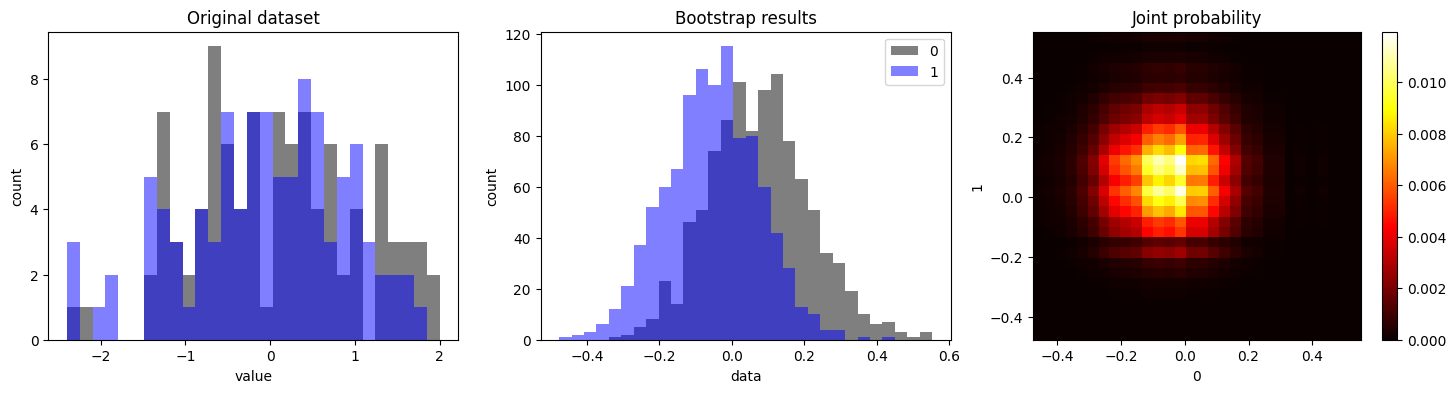

In [3]:
# apply hierarchical bootstrap
res = hierarchical_bootstrap(df, 'data', 'cluster', 'instance', 'condition')

## Option 2: Paired hierarchical bootstrap

Use `paired=True` when the **same clusters appear in both conditions** (e.g., the same animal is measured before and after a treatment). This accounts for within-cluster correlations across conditions.

p-value: 0.213
True mean difference: -0.13
Condition '0' < '1'


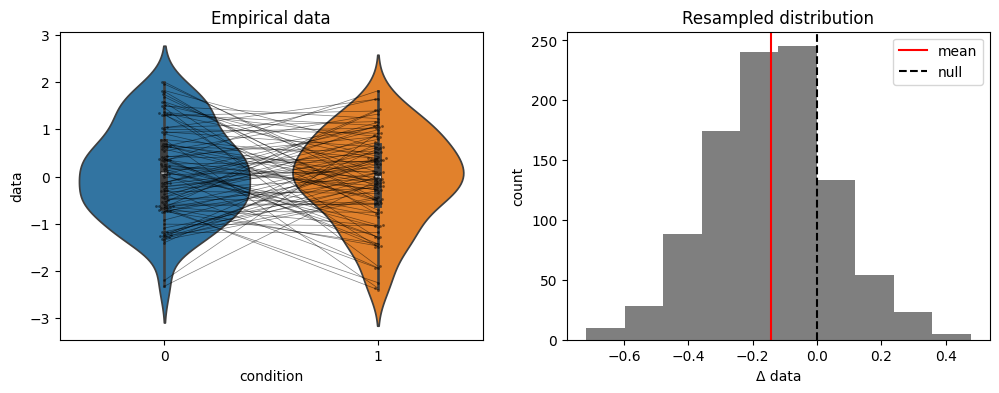

In [4]:
res = hierarchical_bootstrap(df, 'data', 'cluster', 'instance', 'condition',
                             paired=True)

## Option 3: One-sample hierarchical bootstrap

Use `one_sample=True` to test whether the mean of a **single condition** differs from zero — the hierarchical equivalent of a one-sample t-test.

p-value: 0.023


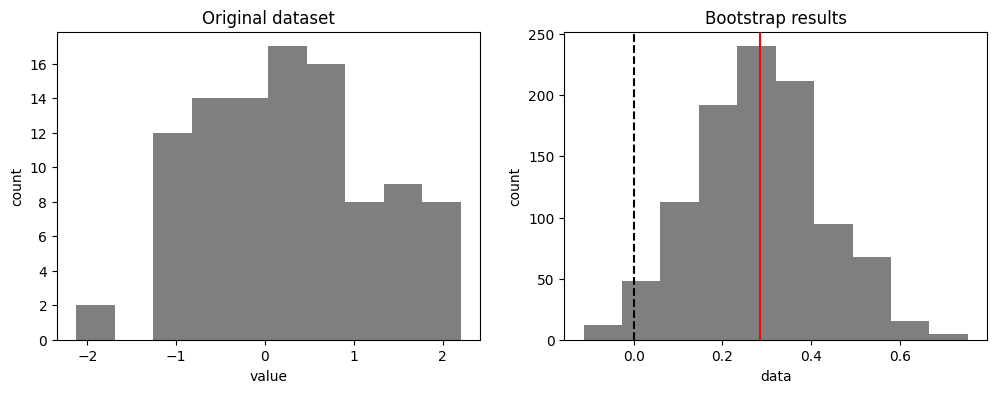

In [6]:
# simulate data 
rng = np.random.default_rng(0)
data = rng.normal(0.2, 1, n_clusters * n_instances)

# create dataframe
cluster = np.repeat(np.arange(n_clusters), n_instances)
instance = np.tile(np.arange(n_instances), n_clusters)
df = pd.DataFrame({"data": data, "cluster": cluster, "instance": instance})

# apply hierarchical bootstrap
res = hierarchical_bootstrap(df, 'data', 'cluster', 'instance', one_sample=True)

That's it for this notebook! You can adapt this code for your own hierarchically structured data by swapping in your dataframe and column names in Steps 3–5.

<hr>

**About this notebook**: This notebook was authored by [Michael Preston](https://www.linkedin.com/in/michael-preston-jr/) and edited by [Ashley Juavinett](http://www.ashleyjuavinett.com)